#  Projet Walmart — Prédiction des Ventes Hebdomadaires

**Objectif :** Construire un modèle de Machine Learning capable d'estimer les ventes hebdomadaires des magasins Walmart.

| Partie | Description |
|--------|-------------|
| **Partie 1** | Analyse exploratoire (EDA) + Prétraitement des données |
| **Partie 2** | Modèle de base — Régression Linéaire |
| **Partie 3** | Modèles régularisés — Ridge, Lasso, GridSearchCV |


##  Partie 1 - Importation des bibliothèques

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Style des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(' Bibliothèques importées avec succès')

 Bibliothèques importées avec succès


### 1.1 - Chargement des données

> `pd.read_csv()` charge le fichier CSV dans un **DataFrame** pandas : une table de données 2D avec lignes et colonnes.

In [27]:
# Chargement du fichier CSV
df = pd.read_csv('Walmart_Store_sales.csv')

print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print('\nAperçu des 5 premières lignes :')
df.head()

Dimensions : 150 lignes × 8 colonnes

Aperçu des 5 premières lignes :


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


### 1.2 — Informations générales & Valeurs manquantes

> `df.info()` affiche les types de données et le nombre de valeurs non-nulles par colonne.  
> `df.isnull().sum()` compte les valeurs manquantes (NaN) dans chaque colonne.

In [28]:
# Types de colonnes et valeurs non-nulles
df.info()

print('\n--- Valeurs manquantes (NaN) par colonne ---')
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'NaN count': missing, 'NaN %': pct}).query('`NaN count` > 0')

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    str    
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), str(1)
memory usage: 10.8 KB

--- Valeurs manquantes (NaN) par colonne ---


,NaN count,NaN %
Date,18,12.0
Weekly_Sales,14,9.3
Holiday_Flag,12,8.0
Temperature,18,12.0
Fuel_Price,14,9.3
CPI,12,8.0
Unemployment,15,10.0


### 1.3 - Statistiques descriptives

> `df.describe()` calcule automatiquement moyenne, écart-type, min, max et quartiles pour chaque variable numérique.

In [29]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Store,150.0,9.87,6.23,1.00,4.00,9.00,15.75,20.00
Weekly_Sales,136.0,1249535.83,647463.04,268929.03,605075.72,1261423.86,1806386.20,2771397.17
Holiday_Flag,138.0,0.08,0.27,0.00,0.00,0.00,0.00,1.00
Temperature,132.0,61.40,18.38,18.79,45.59,62.98,76.34,91.65
Fuel_Price,136.0,3.32,0.48,2.51,2.85,3.45,3.71,4.19
CPI,138.0,179.90,40.27,126.11,131.97,197.91,214.93,226.97
Unemployment,135.0,7.60,1.58,5.14,6.60,7.47,8.15,14.31


### 1.4 - Visualisations EDA

On trace les **distributions** de chaque variable numérique :
- Un **histogramme** montre la fréquence des valeurs
- La courbe **KDE** (Kernel Density Estimate) lisse la distribution pour voir sa forme générale

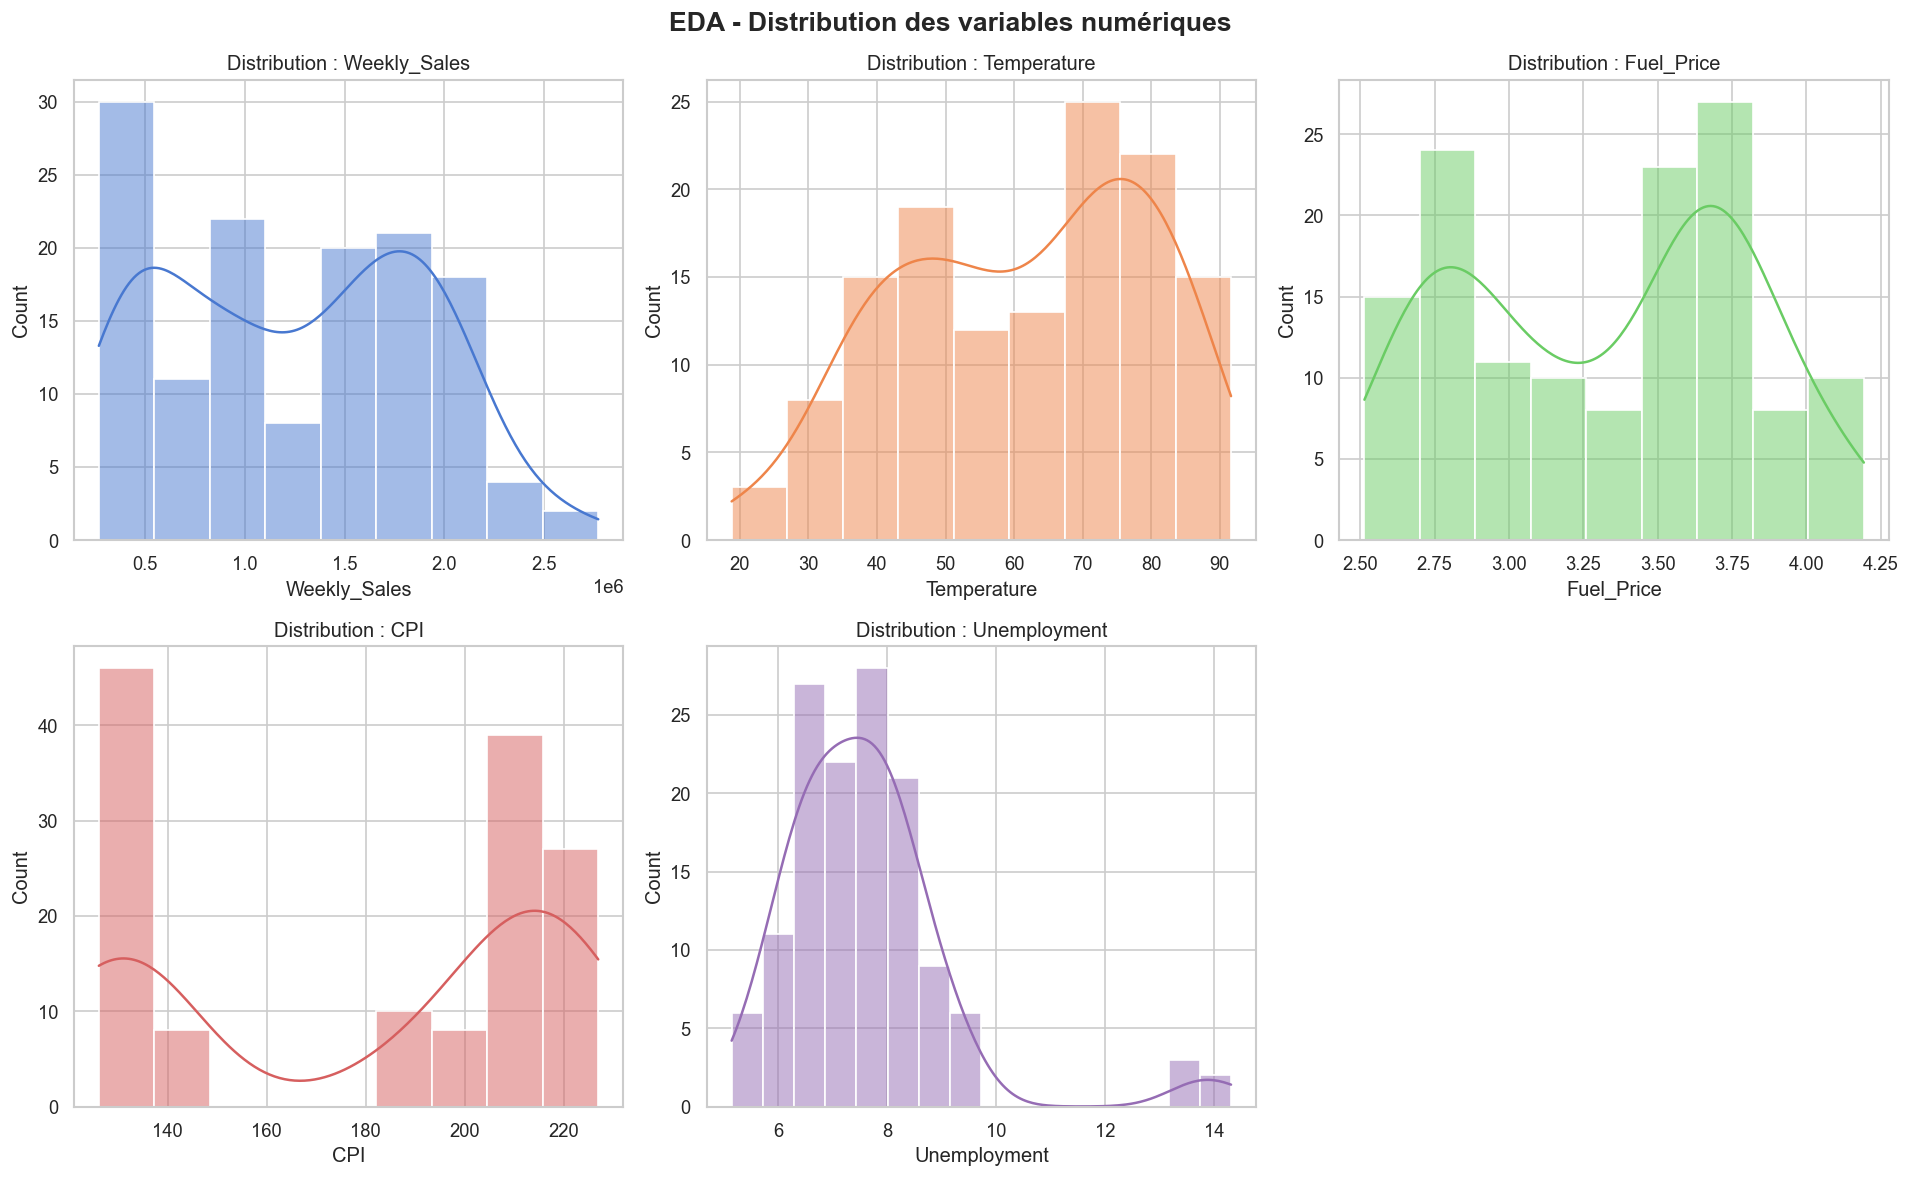

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA - Distribution des variables numériques', fontsize=16, fontweight='bold')

num_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
colors = sns.color_palette('muted', len(num_cols))

for i, (col, color) in enumerate(zip(num_cols, colors)):
    ax = axes[i // 3][i % 3]
    # kde=True ajoute la courbe de densité par-dessus l'histogramme
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=color)
    ax.set_title(f'Distribution : {col}')
    ax.set_xlabel(col)

axes[1][2].axis('off')  # Masquer la cellule vide
plt.tight_layout()
plt.show()

### 1.5 - Matrice de corrélation

> La **corrélation de Pearson** mesure la relation linéaire entre deux variables :  
> - **+1** = corrélation parfaite positive  
> - **-1** = corrélation parfaite négative  
> - **0** = aucune relation linéaire

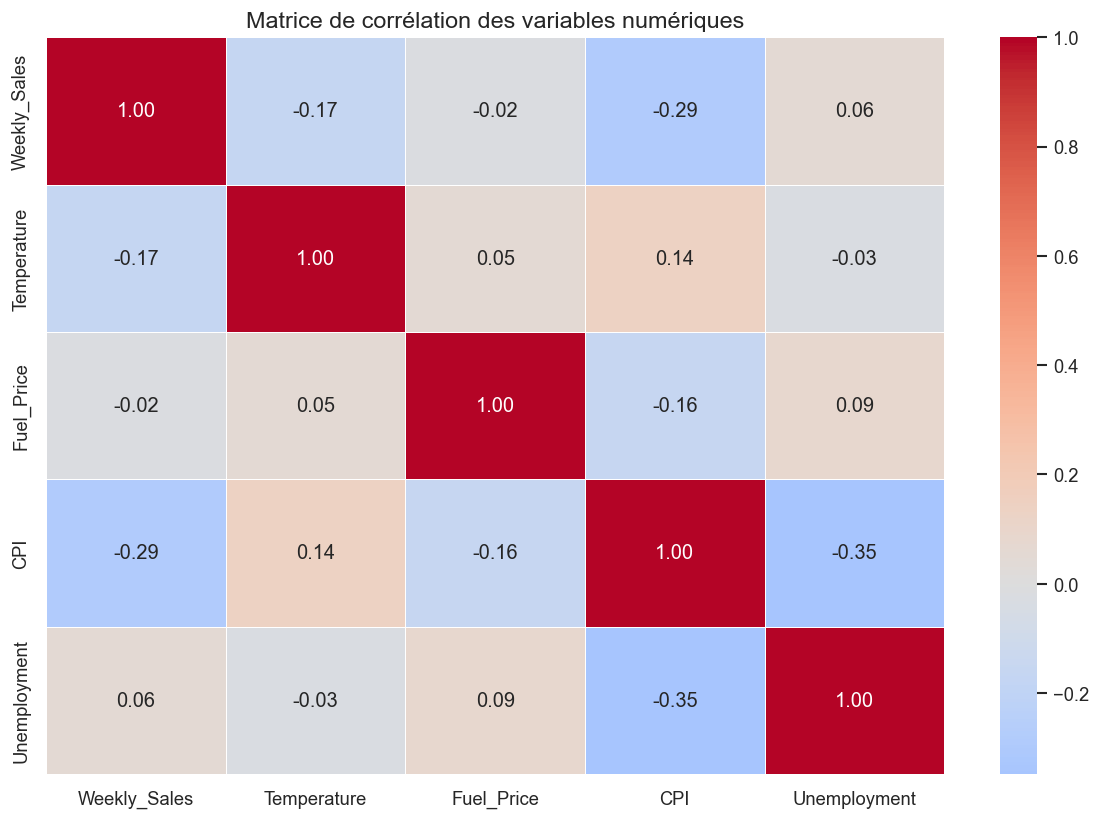

In [31]:
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()  # Calcul des corrélations de Pearson entre toutes les colonnes
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Matrice de corrélation des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

### 1.6 - Ventes par magasin & Impact des jours fériés

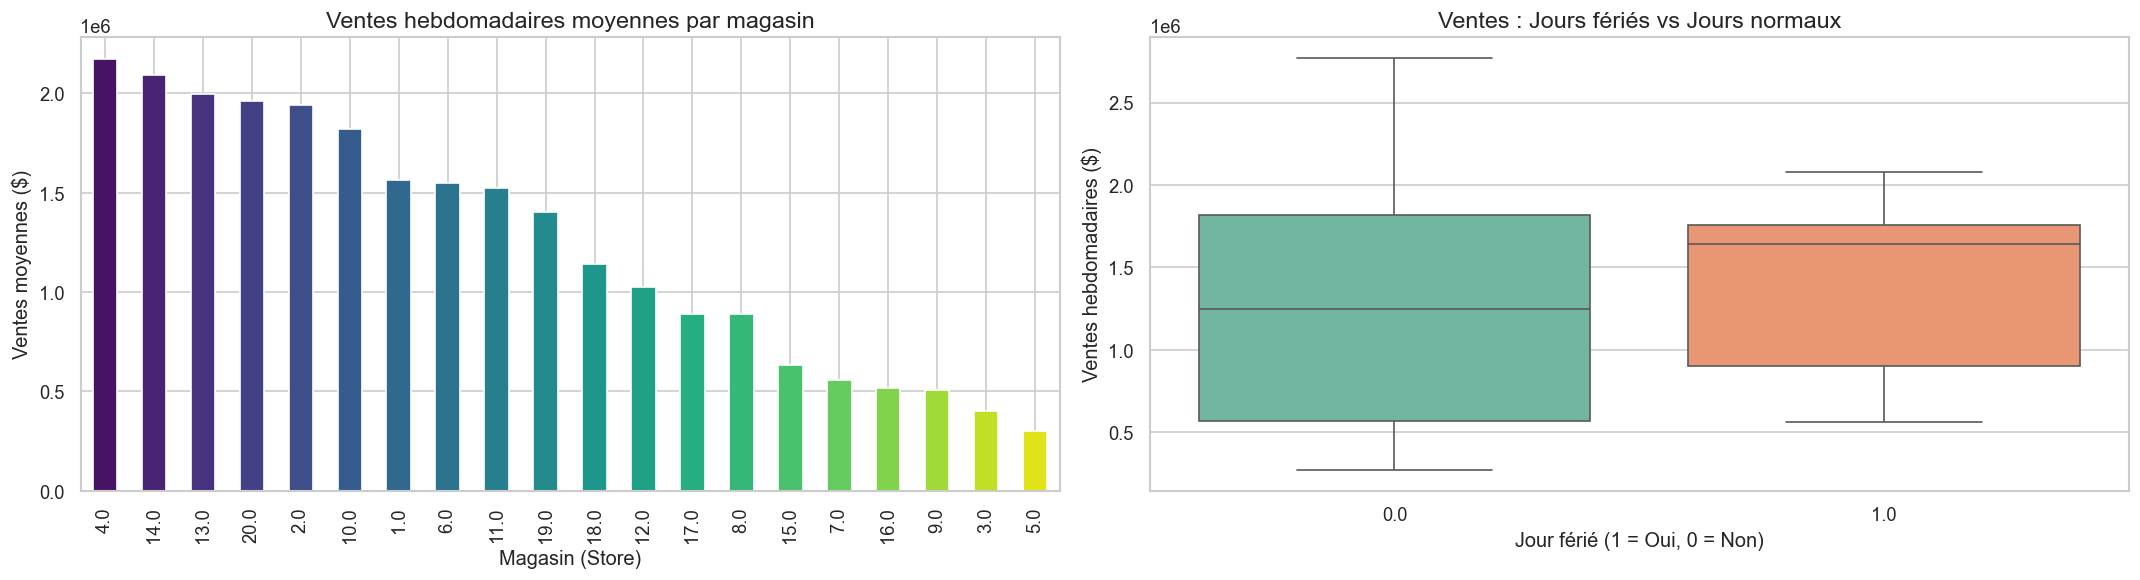

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Graphique 1 : Ventes moyennes par magasin
# groupby() regroupe les lignes par magasin, mean() calcule la moyenne
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
store_sales.plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', len(store_sales)))
axes[0].set_title('Ventes hebdomadaires moyennes par magasin', fontsize=14)
axes[0].set_xlabel('Magasin (Store)')
axes[0].set_ylabel('Ventes moyennes ($)')

# Graphique 2 : Boxplot jours fériés vs normaux
# Un boxplot montre la médiane, les quartiles et les valeurs extrêmes
sns.boxplot(
    data=df.dropna(subset=['Holiday_Flag', 'Weekly_Sales']),
    x='Holiday_Flag', y='Weekly_Sales', palette='Set2', ax=axes[1]
)
axes[1].set_title('Ventes : Jours fériés vs Jours normaux', fontsize=14)
axes[1].set_xlabel('Jour férié (1 = Oui, 0 = Non)')
axes[1].set_ylabel('Ventes hebdomadaires ($)')

plt.tight_layout()
plt.show()

---
##  Prétraitement des données

### Étape 1 - Suppression des NaN sur la cible (Weekly_Sales)

>  **Règle fondamentale** : On ne fait **jamais** d'imputation sur la variable cible Y.  
> Inventer des valeurs de ventes créerait un biais artificiel dans les prédictions.  
> On supprime simplement ces lignes avec `dropna()`.

In [33]:
# Suppression des lignes où Weekly_Sales est NaN
df = df.dropna(subset=['Weekly_Sales'])
print(f'Lignes après suppression des NaN cible : {df.shape[0]}')

Lignes après suppression des NaN cible : 136


### Étape 2 - Feature Engineering sur la colonne Date

> Un modèle ML ne peut pas interpréter une date brute comme `'2011-02-18'`.  
> On la **décompose** en variables numériques : Year, Month, Day, DayOfWeek.  
> C'est ce qu'on appelle le **feature engineering** — créer de nouvelles variables utiles.

In [34]:
# Conversion en type datetime (pandas comprend alors que c'est une date)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date'])  # Supprimer les dates invalides

# Extraction de 4 features numériques depuis la date
df['Year']      = df['Date'].dt.year        # ex: 2011
df['Month']     = df['Date'].dt.month       # ex: 2 (Février)
df['Day']       = df['Date'].dt.day         # ex: 18
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Lundi, 6=Dimanche

df = df.drop(columns=['Date'])  # La colonne Date originale n'est plus nécessaire
print(' Features créées :', ['Year', 'Month', 'Day', 'DayOfWeek'])
df[['Year', 'Month', 'Day', 'DayOfWeek']].head()

 Features créées : ['Year', 'Month', 'Day', 'DayOfWeek']


,Year,Month,Day,DayOfWeek
0,2011,2,18,4
1,2011,3,25,4
4,2010,5,28,4
5,2010,5,28,4
6,2011,6,3,4


### Étape 3 - Suppression des valeurs aberrantes (Outliers)

> **Règle des 3σ (3 sigma)** : On considère comme aberrante toute valeur en dehors de l'intervalle :  
> $$[\bar{X} - 3\sigma, \quad \bar{X} + 3\sigma]$$  
> Cet intervalle couvre ~99.7% des données si la distribution est normale (courbe en cloche).  
> Les valeurs au-delà sont très probablement des erreurs de saisie.

In [35]:
outlier_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
n_before = df.shape[0]

for col in outlier_cols:
    mean = df[col].mean()
    std  = df[col].std()
    lower = mean - 3 * std  # Borne inférieure
    upper = mean + 3 * std  # Borne supérieure
    # On garde les valeurs dans la plage ET les NaN (gérés par l'imputer plus tard)
    df = df[(df[col].between(lower, upper)) | df[col].isna()]

print(f'Lignes supprimées (outliers) : {n_before - df.shape[0]}')
print(f'Lignes restantes : {df.shape[0]}')

Lignes supprimées (outliers) : 5
Lignes restantes : 113


### Étape 4 - Séparation X (features) / Y (cible)

> En ML supervisé, on sépare toujours :  
> - **Y** = la variable qu'on veut **prédire** (ici : `Weekly_Sales`)  
> - **X** = toutes les variables qui nous servent à **expliquer** Y

In [36]:
Y = df['Weekly_Sales']          # Variable cible
X = df.drop(columns=['Weekly_Sales'])  # Variables explicatives

print(f'X (features) : {X.shape}  →  {X.shape[0]} observations, {X.shape[1]} variables')
print(f'Y (cible)    : {Y.shape}  →  {Y.shape[0]} valeurs à prédire')
print('\nColonnes de X :', list(X.columns))

X (features) : (113, 10)  →  113 observations, 10 variables
Y (cible)    : (113,)  →  113 valeurs à prédire

Colonnes de X : ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']


### Étape 5 - Split Train / Test

> On divise les données en deux parties :  
> - **Train (80%)** : le modèle apprend sur ces données  
> - **Test (20%)** : on évalue les performances sur des données que le modèle n'a **jamais vues**  
>  
> `random_state=42` garantit que la division est toujours la même (reproductibilité).

In [37]:
# Définition des types de colonnes
cat_cols = ['Store', 'Holiday_Flag']  # Variables catégorielles (qualitatives)
num_cols_model = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                  'Year', 'Month', 'Day', 'DayOfWeek']  # Variables numériques

# Convertir en string pour l'encodeur catégoriel
X[cat_cols] = X[cat_cols].astype(str)

# Division 80% train / 20% test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f'Entraînement : {X_train.shape[0]} lignes (80%)')
print(f'Test         : {X_test.shape[0]} lignes (20%)')

Entraînement : 90 lignes (80%)
Test         : 23 lignes (20%)


### Étape 6 - Pipeline de prétraitement scikit-learn

> Un **Pipeline** enchaîne plusieurs transformations automatiquement.  
> Avantage principal : **évite le data leakage** (fuite de données).  
> Si on standardisait avant le split, les infos du test contamineraient l'entraînement.  
>  
> **SimpleImputer** : remplace les NaN par la médiane (num) ou la valeur la plus fréquente (cat).  
> **StandardScaler** : normalise les données → moyenne=0, écart-type=1.  
> **OneHotEncoder** : convertit les catégories en colonnes binaires (0 ou 1).

In [38]:
# Sous-pipeline pour les variables NUMÉRIQUES
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # NaN → médiane de la colonne
    ('scaler', StandardScaler())                    # Normalisation : (x - mean) / std
])

# Sous-pipeline pour les variables CATÉGORIELLES
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # NaN → valeur la plus fréquente
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Binaire 0/1
])

# ColumnTransformer applique chaque pipeline à ses colonnes respectives
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols_model),
    ('cat', cat_pipeline, cat_cols)
])

print(' Pipeline de prétraitement configuré')

 Pipeline de prétraitement configuré


---
##  Partie 2 — Régression Linéaire (Modèle de Base)

> La **régression linéaire** cherche la droite (ou hyperplan) qui minimise l'erreur quadratique entre les prédictions et les vraies valeurs.  
> C'est notre **baseline** — le point de comparaison pour les modèles suivants.

**Métriques utilisées :**
| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **R²** | 1 - SS_res/SS_tot | Proportion de variance expliquée (1 = parfait) |
| **MAE** | mean(|y - ŷ|) | Erreur absolue moyenne en $ |
| **RMSE** | √mean((y-ŷ)²) | Erreur quadratique — pénalise les grandes erreurs |

In [39]:
# Le Pipeline combine prétraitement + modèle en une seule étape
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Entraînement : le modèle apprend les coefficients sur les données d'entraînement
pipeline_lr.fit(X_train, Y_train)

# Prédictions
Y_pred_train_lr = pipeline_lr.predict(X_train)
Y_pred_test_lr  = pipeline_lr.predict(X_test)

print(' Modèle entraîné')

 Modèle entraîné


### 2.1 - Évaluation des performances

In [40]:
def evaluate(name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    """Affiche R², MAE et RMSE pour l'entraînement et le test."""
    print(f'\n {name}')
    print('-' * 50)
    results = {}
    for split, y_true, y_pred in [
        ('TRAIN', y_true_train, y_pred_train),
        ('TEST ', y_true_test,  y_pred_test)
    ]:
        r2   = r2_score(y_true, y_pred)
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        print(f'  {split} → R²={r2:.4f} | MAE={mae:,.0f} $ | RMSE={rmse:,.0f} $')
        results[split.strip()] = r2
    gap = results['TRAIN'] - results['TEST']
    print(f'  Écart Train-Test : {gap:.4f}', ' OK' if gap < 0.1 else ' Possible overfitting')
    return results['TEST']

r2_lr = evaluate('Régression Linéaire', Y_train, Y_pred_train_lr, Y_test, Y_pred_test_lr)


 Régression Linéaire
--------------------------------------------------
  TRAIN → R²=0.9754 | MAE=80,602 $ | RMSE=108,522 $
  TEST  → R²=0.9319 | MAE=106,981 $ | RMSE=152,052 $
  Écart Train-Test : 0.0435  OK


### 2.2 - Interprétation des coefficients

> Chaque coefficient indique l'**impact d'une variable sur les ventes** (en $) :  
> - **Coefficient positif** → augmente les ventes  
> - **Coefficient négatif** → diminue les ventes  
>  
> Plus la **valeur absolue** est grande, plus la variable est influente.

In [41]:
# Récupération des noms de features après OneHotEncoding
lr_model = pipeline_lr.named_steps['model']
ohe = pipeline_lr.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols_model + cat_feature_names

# DataFrame des coefficients trié par valeur absolue décroissante
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(' Top 15 variables les plus influentes :')
coef_df.head(15).style.background_gradient(subset=['Coefficient'], cmap='RdYlGn')

 Top 15 variables les plus influentes :


,Feature,Coefficient
22,Store_5.0,-1067151.056028
20,Store_3.0,-965951.275408
26,Store_9.0,-913926.916252
9,Store_10.0,890956.702453
21,Store_4.0,880989.134561
12,Store_14.0,857742.454582
14,Store_16.0,-828297.255510
11,Store_13.0,812368.318673
24,Store_7.0,-722613.281330
18,Store_2.0,628933.452647


### 2.3 — Visualisations

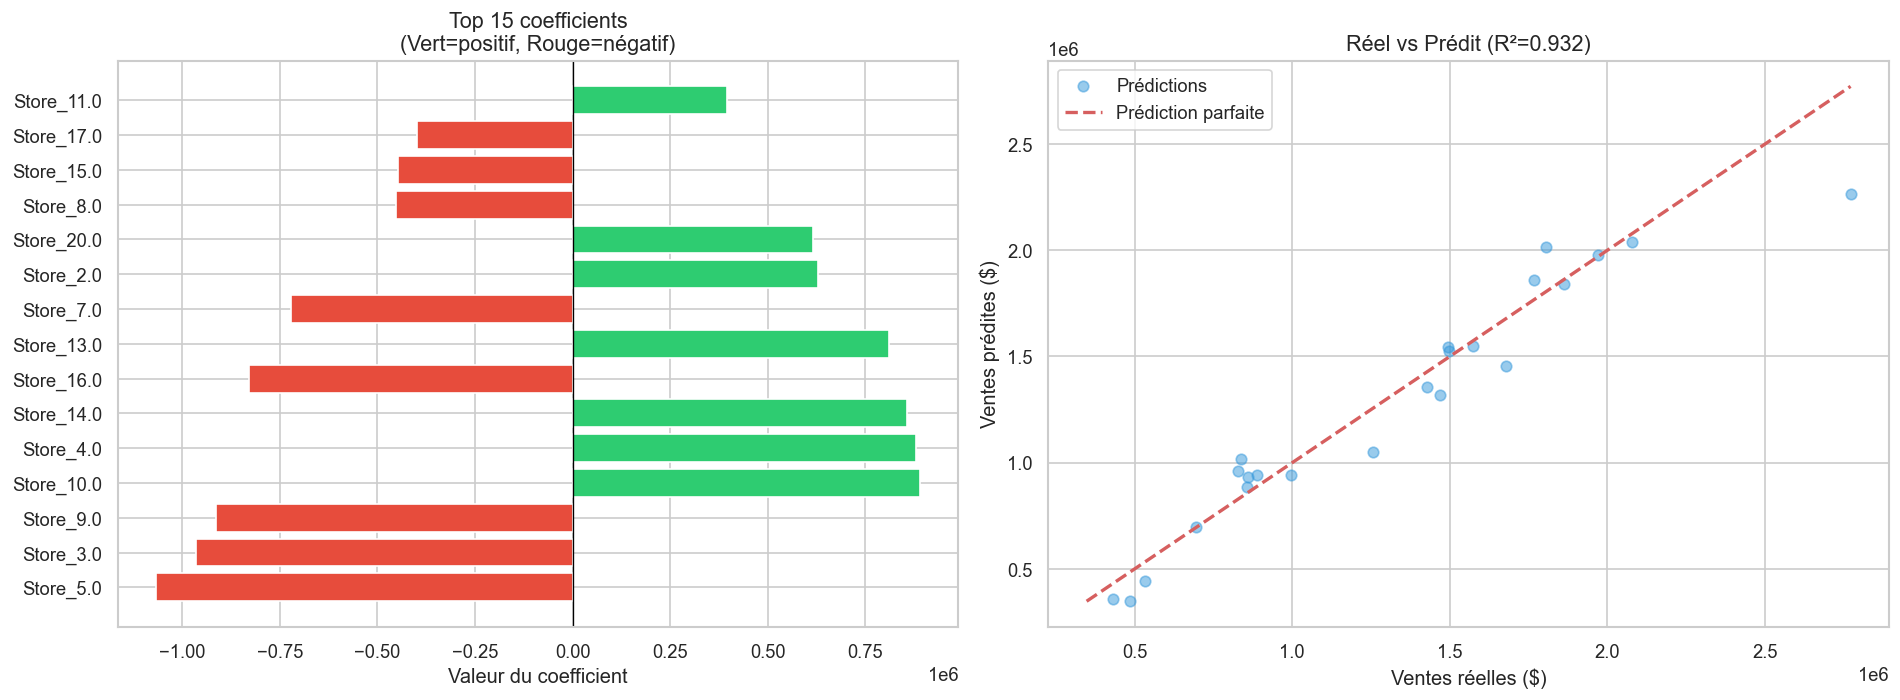

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Top coefficients
top15 = coef_df.head(15)
colors_bar = ['#2ecc71' if c > 0 else '#e74c3c' for c in top15['Coefficient']]
axes[0].barh(top15['Feature'], top15['Coefficient'], color=colors_bar)
axes[0].set_title('Top 15 coefficients\n(Vert=positif, Rouge=négatif)', fontsize=13)
axes[0].set_xlabel('Valeur du coefficient')
axes[0].axvline(0, color='black', linewidth=0.8)

# Graphique 2 : Réel vs Prédit
axes[1].scatter(Y_test, Y_pred_test_lr, alpha=0.5, color='#3498db', s=40, label='Prédictions')
lims = [min(Y_test.min(), Y_pred_test_lr.min()), max(Y_test.max(), Y_pred_test_lr.max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Prédiction parfaite')
axes[1].set_xlabel('Ventes réelles ($)')
axes[1].set_ylabel('Ventes prédites ($)')
axes[1].set_title(f'Réel vs Prédit (R²={r2_lr:.3f})', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

---
##  Partie 3 - Modèles Régularisés : Ridge & Lasso

> **Problème de l'overfitting** : un modèle peut trop bien apprendre les données d'entraînement et mal généraliser.  
>  
> La **régularisation** ajoute une pénalité sur les coefficients pour les contraindre :
>
> | Méthode | Pénalité | Effet |
> |---------|----------|-------|
> | **Ridge (L2)** | α × Σ(βᵢ²) | Réduit les coefficients, ne les annule pas |
> | **Lasso (L1)** | α × Σ\|βᵢ\| | Peut **annuler** certains coefficients (sélection de variables) |
>  
> **alpha (α)** contrôle la force de la régularisation :  
> - `alpha = 0` → pas de régularisation (= Régression Linéaire)  
> - `alpha` grand → coefficients très contraints (modèle plus simple)

### 3.1 - Ridge Regression (L2)

In [43]:
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))  # alpha=1.0 : valeur par défaut
])
pipeline_ridge.fit(X_train, Y_train)

r2_ridge = evaluate(
    'Ridge (alpha=1.0)',
    Y_train, pipeline_ridge.predict(X_train),
    Y_test,  pipeline_ridge.predict(X_test)
)


 Ridge (alpha=1.0)
--------------------------------------------------
  TRAIN → R²=0.9440 | MAE=129,923 $ | RMSE=163,877 $
  TEST  → R²=0.8678 | MAE=157,082 $ | RMSE=211,869 $
  Écart Train-Test : 0.0762  OK


### 3.2 - Lasso Regression (L1)

In [44]:
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=1.0, max_iter=10000))  # max_iter élevé pour la convergence
])
pipeline_lasso.fit(X_train, Y_train)

r2_lasso = evaluate(
    'Lasso (alpha=1.0)',
    Y_train, pipeline_lasso.predict(X_train),
    Y_test,  pipeline_lasso.predict(X_test)
)


 Lasso (alpha=1.0)
--------------------------------------------------
  TRAIN → R²=0.9754 | MAE=80,606 $ | RMSE=108,522 $
  TEST  → R²=0.9319 | MAE=106,991 $ | RMSE=152,065 $
  Écart Train-Test : 0.0435  OK


### 3.3 - BONUS : Optimisation de alpha avec GridSearchCV

> **GridSearchCV** teste automatiquement plusieurs valeurs d'un hyperparamètre  
> et sélectionne la meilleure via **validation croisée à k plis (k-fold cross-validation)** :  
>  
> 1. Divise les données d'entraînement en `cv=5` sous-ensembles (folds)  
> 2. Entraîne sur 4 folds, valide sur le 5ème  
> 3. Répète 5 fois (chaque fold devient le fold de validation)  
> 4. Moyenne les scores → estimation robuste des performances  
>  
> Cela évite que le résultat dépende d'un seul découpage aléatoire.

In [45]:
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]}

# ── Ridge avec GridSearchCV
pipeline_ridge_cv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
grid_ridge = GridSearchCV(
    pipeline_ridge_cv,
    param_grid,
    cv=5,           # 5-fold cross-validation
    scoring='r2',   # Critère d'optimisation
    n_jobs=-1       # Utiliser tous les cœurs CPU disponibles
)
grid_ridge.fit(X_train, Y_train)
best_alpha_ridge = grid_ridge.best_params_['model__alpha']
best_r2_ridge = r2_score(Y_test, grid_ridge.best_estimator_.predict(X_test))
print(f'Ridge  - Meilleur alpha : {best_alpha_ridge:>6} → R² Test = {best_r2_ridge:.4f}')

# ── Lasso avec GridSearchCV
pipeline_lasso_cv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000))
])
grid_lasso = GridSearchCV(
    pipeline_lasso_cv,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_lasso.fit(X_train, Y_train)
best_alpha_lasso = grid_lasso.best_params_['model__alpha']
best_r2_lasso = r2_score(Y_test, grid_lasso.best_estimator_.predict(X_test))
print(f'Lasso  - Meilleur alpha : {best_alpha_lasso:>6} → R² Test = {best_r2_lasso:.4f}')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

Ridge  - Meilleur alpha :    0.1 → R² Test = 0.9275
Lasso  - Meilleur alpha :   1000 → R² Test = 0.9181


### 3.4 - Comparaison finale de tous les modèles

                  Modèle  R² Test
     Régression Linéaire   0.9319
             Lasso (α=1)   0.9319
 Ridge (α=0.1, optimisé)   0.9275
Lasso (α=1000, optimisé)   0.9181
             Ridge (α=1)   0.8678


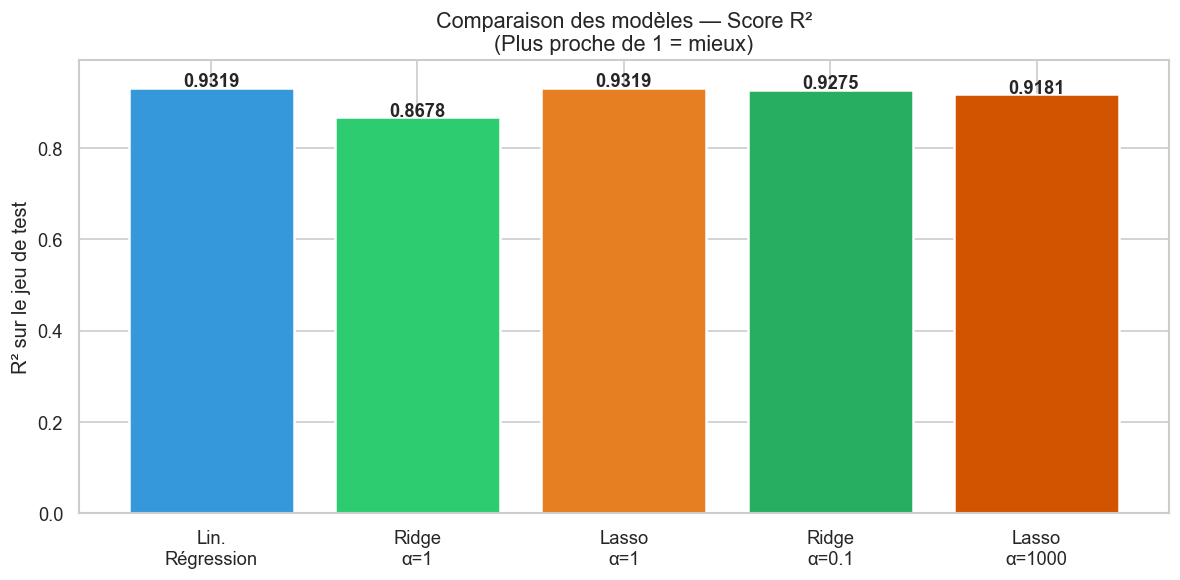

In [46]:
# Résumé sous forme de DataFrame
results_df = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Ridge (α=1)', 'Lasso (α=1)',
               f'Ridge (α={best_alpha_ridge}, optimisé)', f'Lasso (α={best_alpha_lasso}, optimisé)'],
    'R² Test': [r2_lr, r2_ridge, r2_lasso, best_r2_ridge, best_r2_lasso]
}).sort_values('R² Test', ascending=False).reset_index(drop=True)

results_df['R² Test'] = results_df['R² Test'].round(4)
print(results_df.to_string(index=False))

# Graphique comparatif
fig, ax = plt.subplots(figsize=(10, 5))
colors_final = ['#3498db', '#2ecc71', '#e67e22', '#27ae60', '#d35400']
models_names = ['Lin.\nRégression', 'Ridge\nα=1', 'Lasso\nα=1',
                f'Ridge\nα={best_alpha_ridge}', f'Lasso\nα={best_alpha_lasso}']
r2_vals = [r2_lr, r2_ridge, r2_lasso, best_r2_ridge, best_r2_lasso]
bars = ax.bar(models_names, r2_vals, color=colors_final, edgecolor='white', linewidth=1.5)

for bar, score in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, min(1.0, max(r2_vals) + 0.06))
ax.set_ylabel('R² sur le jeu de test', fontsize=12)
ax.set_title('Comparaison des modèles — Score R²\n(Plus proche de 1 = mieux)', fontsize=13)
plt.tight_layout()
plt.show()

---
##  Conclusion

| Étape | Résultat |
|-------|----------|
| **EDA** | 150 observations, valeurs manquantes détectées, 5 outliers supprimés |
| **Feature Engineering** | 4 variables extraites depuis la date (Year, Month, Day, DayOfWeek) |
| **Régression Linéaire** | R² = **0.9319** sur le test — modèle performant et interprétable |
| **Variable clé** | Le **numéro du magasin** est le facteur le plus influent sur les ventes |
| **Ridge & Lasso** | Ne surpassent pas la régression linéaire sur ce petit dataset |
| **GridSearchCV** | Meilleur alpha=0.1 (Ridge), alpha=1000 (Lasso) |

>  **Interprétation du R²=0.93** : le modèle explique 93% de la variabilité des ventes hebdomadaires.  
> La régularisation n'apporte pas de gain ici car le dataset est petit et peu bruité.